# Pharmaceutical Sales — Exploratory Data Analysis
---
**Objective:** Explore pharmacy sales data across 8 ATC drug categories at hourly, daily, weekly, and monthly granularities.

| Code | Class | Example |
|------|-------|---------|
| M01AB | Anti-inflammatory | Diclofenac |
| M01AE | Anti-inflammatory | Ibuprofen |
| N02BA | Analgesics | Aspirin |
| N02BE | Analgesics | Paracetamol |
| N05B | Anxiolytics | Diazepam |
| N05C | Hypnotics/Sedatives | Zolpidem |
| R03 | Anti-asthma | Salbutamol |
| R06 | Antihistamines | Loratadine |

## 1. Setup & Configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "axes.titleweight": "bold"})

# Drug columns and labels
DRUG_COLS = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
DRUG_LABELS = {
    "M01AB": "M01AB (Anti-inflam.)",
    "M01AE": "M01AE (Ibuprofen class)",
    "N02BA": "N02BA (Aspirin class)",
    "N02BE": "N02BE (Paracetamol class)",
    "N05B":  "N05B (Anxiolytics)",
    "N05C":  "N05C (Sedatives)",
    "R03":   "R03 (Anti-asthma)",
    "R06":   "R06 (Antihistamines)",
}

print("Setup complete ✓")

Setup complete ✓


## 2. Data Loading

In [4]:
# Load all four granularities
df_monthly = pd.read_csv("salesmonthly.csv", parse_dates=["datum"])
df_weekly  = pd.read_csv("salesweekly.csv",  parse_dates=["datum"])
df_daily   = pd.read_csv("salesdaily.csv",   parse_dates=["datum"])
df_hourly  = pd.read_csv("saleshourly.csv",  parse_dates=["datum"])

for name, df in [("Monthly", df_monthly), ("Weekly", df_weekly),
                 ("Daily", df_daily), ("Hourly", df_hourly)]:
    print(f"{name:8s} → {df.shape[0]:>6,} rows × {df.shape[1]} cols  "
          f"| {df['datum'].min().date()} → {df['datum'].max().date()}")

Monthly  →     70 rows × 9 cols  | 2014-01-31 → 2019-10-31
Weekly   →    302 rows × 9 cols  | 2014-01-05 → 2019-10-13
Daily    →  2,106 rows × 13 cols  | 2014-01-02 → 2019-10-08
Hourly   → 50,532 rows × 13 cols  | 2014-01-02 → 2019-10-08


## 3. Dataset Overview

In [5]:
# Monthly data — first look
print("=== Monthly Data Types ===")
print(df_monthly.dtypes)
print(f"\nMemory usage: {df_monthly.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df_monthly.head()

=== Monthly Data Types ===
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object

Memory usage: 0.01 MB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [6]:
# Daily data — first look
print("=== Daily Data Types ===")
print(df_daily.dtypes)
df_daily.head()

=== Daily Data Types ===
datum           datetime64[ns]
M01AB                  float64
M01AE                  float64
N02BA                  float64
N02BE                  float64
N05B                   float64
N05C                   float64
R03                    float64
R06                    float64
Year                     int64
Month                    int64
Hour                     int64
Weekday Name            object
dtype: object


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## 4. Missing Values Analysis

In [7]:
# Check missing values across all datasets
for name, df in [("Monthly", df_monthly), ("Weekly", df_weekly),
                 ("Daily", df_daily), ("Hourly", df_hourly)]:
    total_missing = df.isnull().sum().sum()
    print(f"{name:8s} → Total missing values: {total_missing}")

# Detailed per-column report for monthly
missing = df_monthly.isnull().sum()
pct = (missing / len(df_monthly) * 100).round(2)
pd.DataFrame({"count": missing, "pct (%)": pct}).query("count > 0")

Monthly  → Total missing values: 0
Weekly   → Total missing values: 0
Daily    → Total missing values: 0
Hourly   → Total missing values: 0


,count,pct (%)


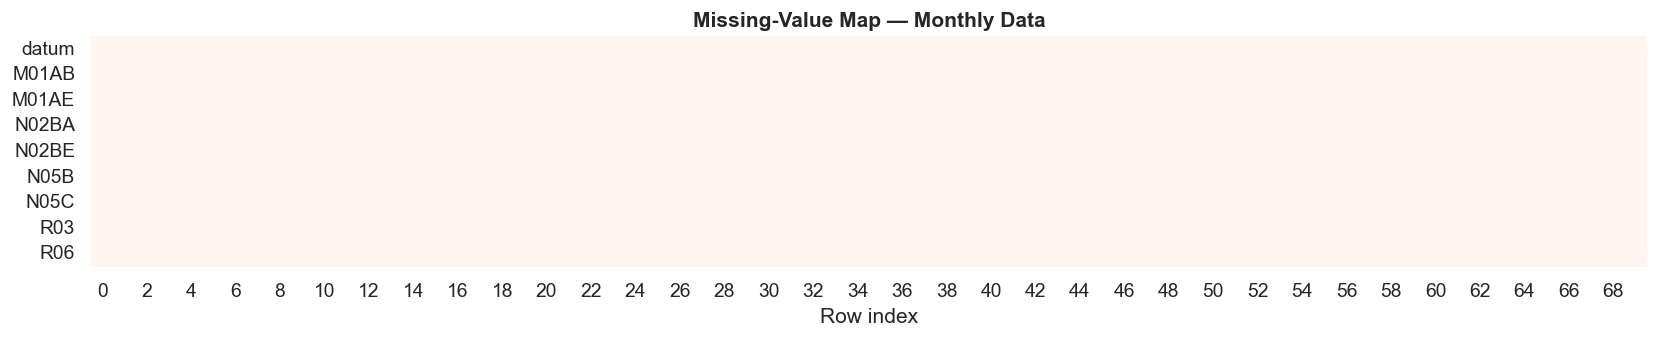

In [8]:
# Missing value heatmap for monthly data
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(df_monthly.isnull().T, cbar=False, cmap="Reds", ax=ax)
ax.set_title("Missing-Value Map — Monthly Data")
ax.set_xlabel("Row index")
plt.tight_layout()
plt.show()

In [9]:
# Detect anomalous rows (e.g., all-zero sales in Jan 2017)
zero_mask = df_monthly[DRUG_COLS].sum(axis=1) <= 1.0
print("Rows with near-zero total sales:")
df_monthly[zero_mask][["datum"] + DRUG_COLS]

Rows with near-zero total sales:


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
36,2017-01-31,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 5. Summary Statistics

In [10]:
# Descriptive statistics with coefficient of variation (CV)
stats = df_monthly[DRUG_COLS].describe().T
stats["cv"] = (stats["std"] / stats["mean"]).round(3)
stats["iqr"] = stats["75%"] - stats["25%"]
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,cv,iqr
M01AB,70.0,149.99,31.49,0.0,137.49,154.64,169.00,211.13,0.21,31.51
M01AE,70.0,116.51,27.89,0.0,103.52,114.84,128.36,222.35,0.24,24.84
N02BA,70.0,115.02,31.25,0.0,94.38,117.22,133.84,191.60,0.27,39.46
N02BE,70.0,892.54,338.84,0.0,648.19,865.82,1061.58,1856.81,0.38,413.39
N05B,70.0,262.12,85.06,1.0,223.75,250.30,293.65,492.00,0.32,69.90
N05C,70.0,17.84,8.48,0.0,12.00,18.00,23.00,50.00,0.48,11.00
R03,70.0,167.68,81.77,0.0,112.00,160.00,218.25,386.00,0.49,106.25
R06,70.0,86.66,45.86,0.0,49.88,74.10,119.81,213.04,0.53,69.93


## 6. Distribution Plots

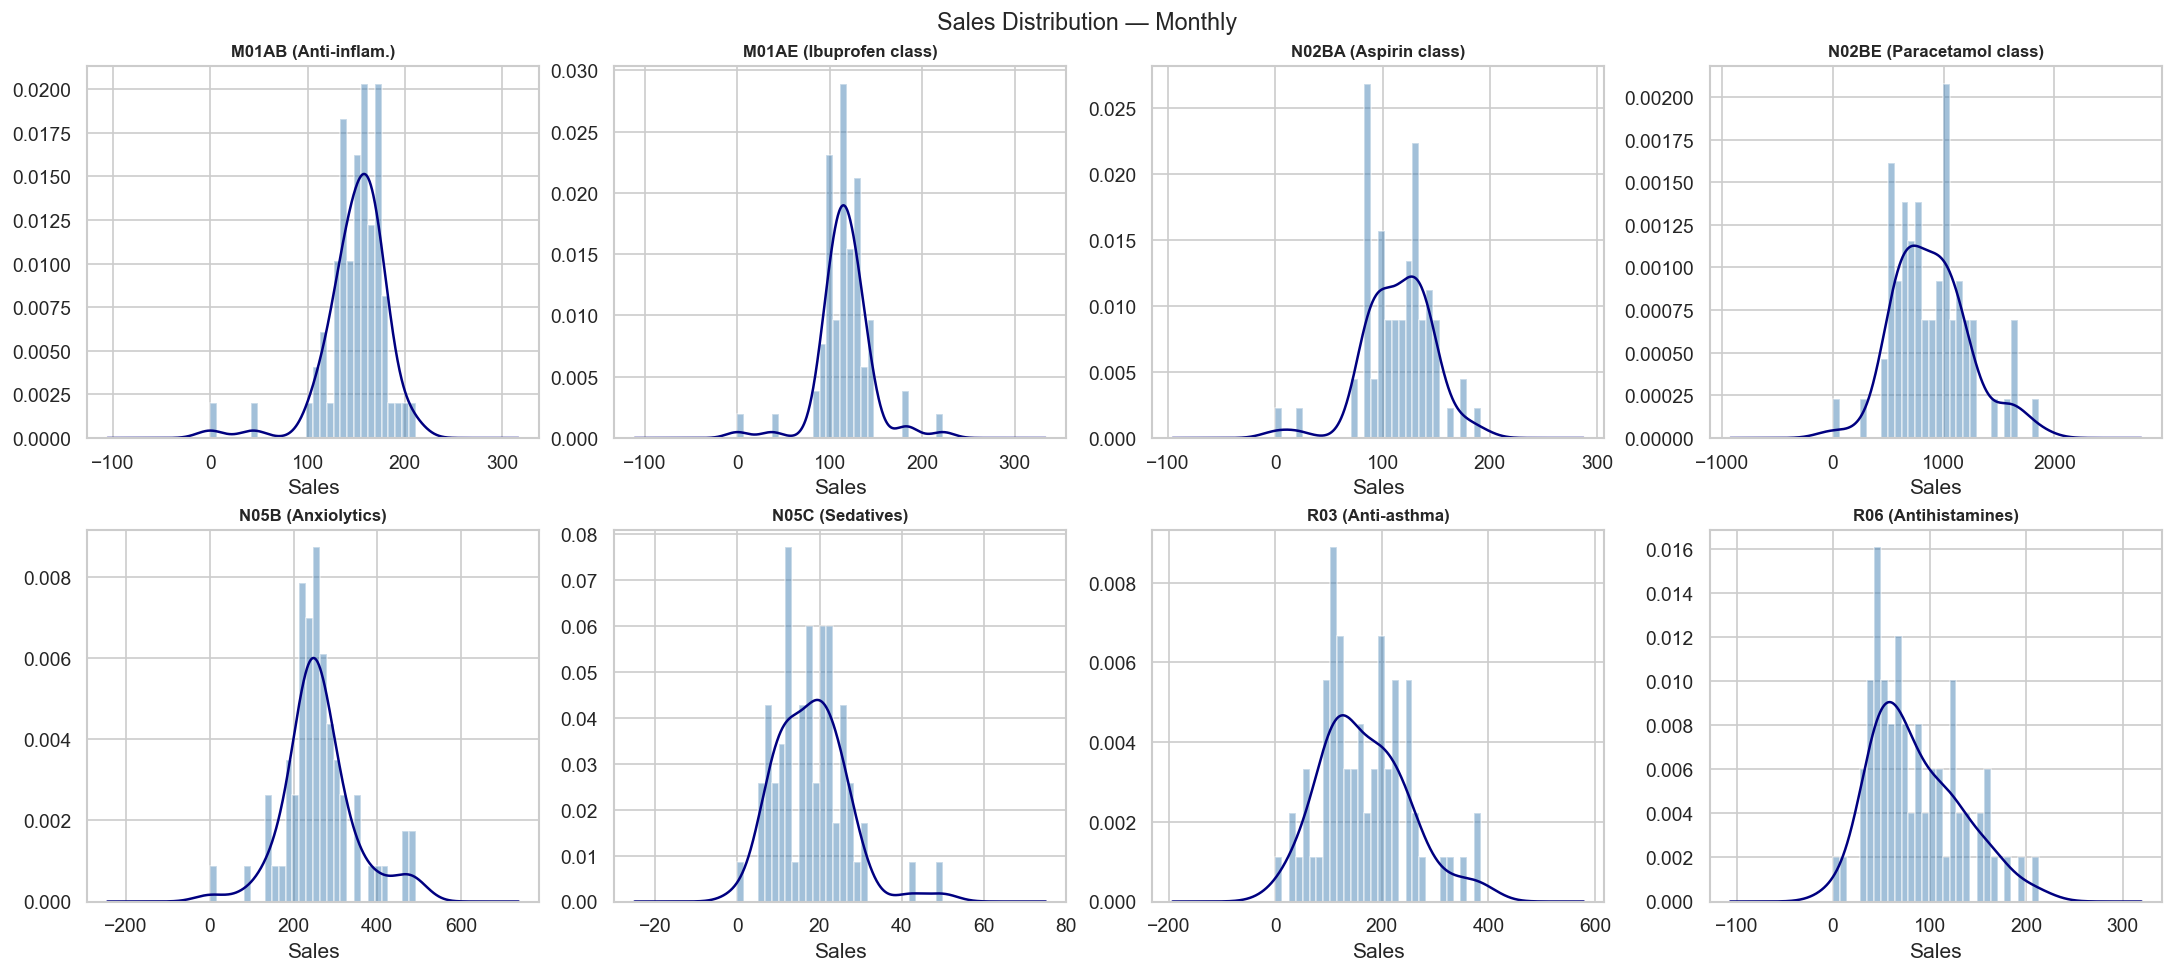

In [11]:
# Histogram + KDE for each drug category
fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
fig.suptitle("Sales Distribution — Monthly", fontsize=14)

for ax, col in zip(axes.ravel(), DRUG_COLS):
    data = df_monthly[col].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.5, color="steelblue", edgecolor="white")
    data.plot.kde(ax=ax, color="navy", linewidth=1.5)
    ax.set_title(DRUG_LABELS[col], fontsize=10)
    ax.set_xlabel("Sales")
    ax.set_ylabel("")

plt.show()

## 7. Correlation Matrix

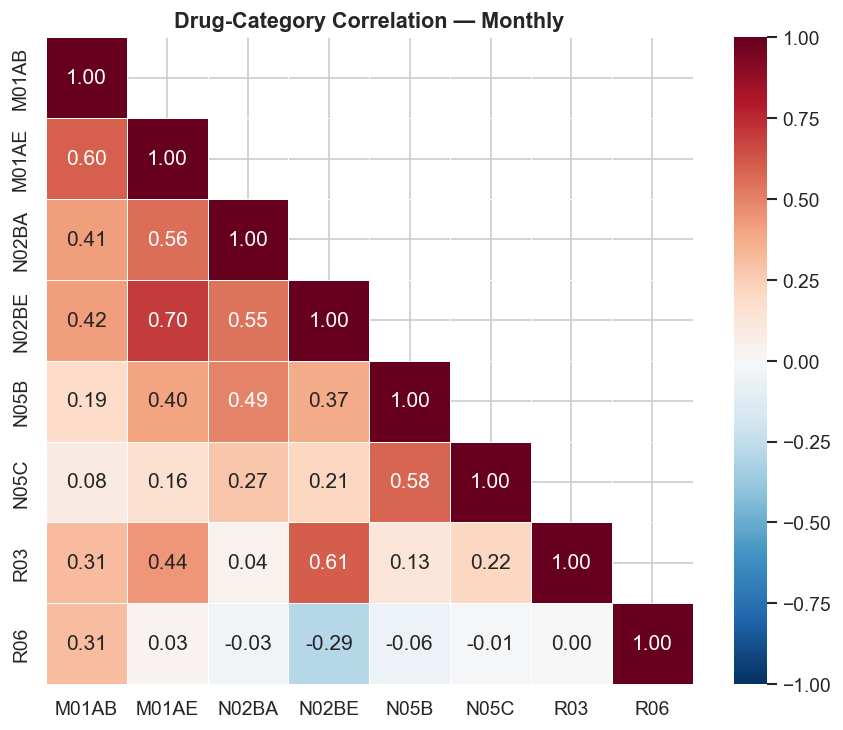

In [12]:
# Pairwise Pearson correlation between drug categories
corr = df_monthly[DRUG_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Drug-Category Correlation — Monthly", fontsize=13)
plt.show()

## 8. Time-Series Trends

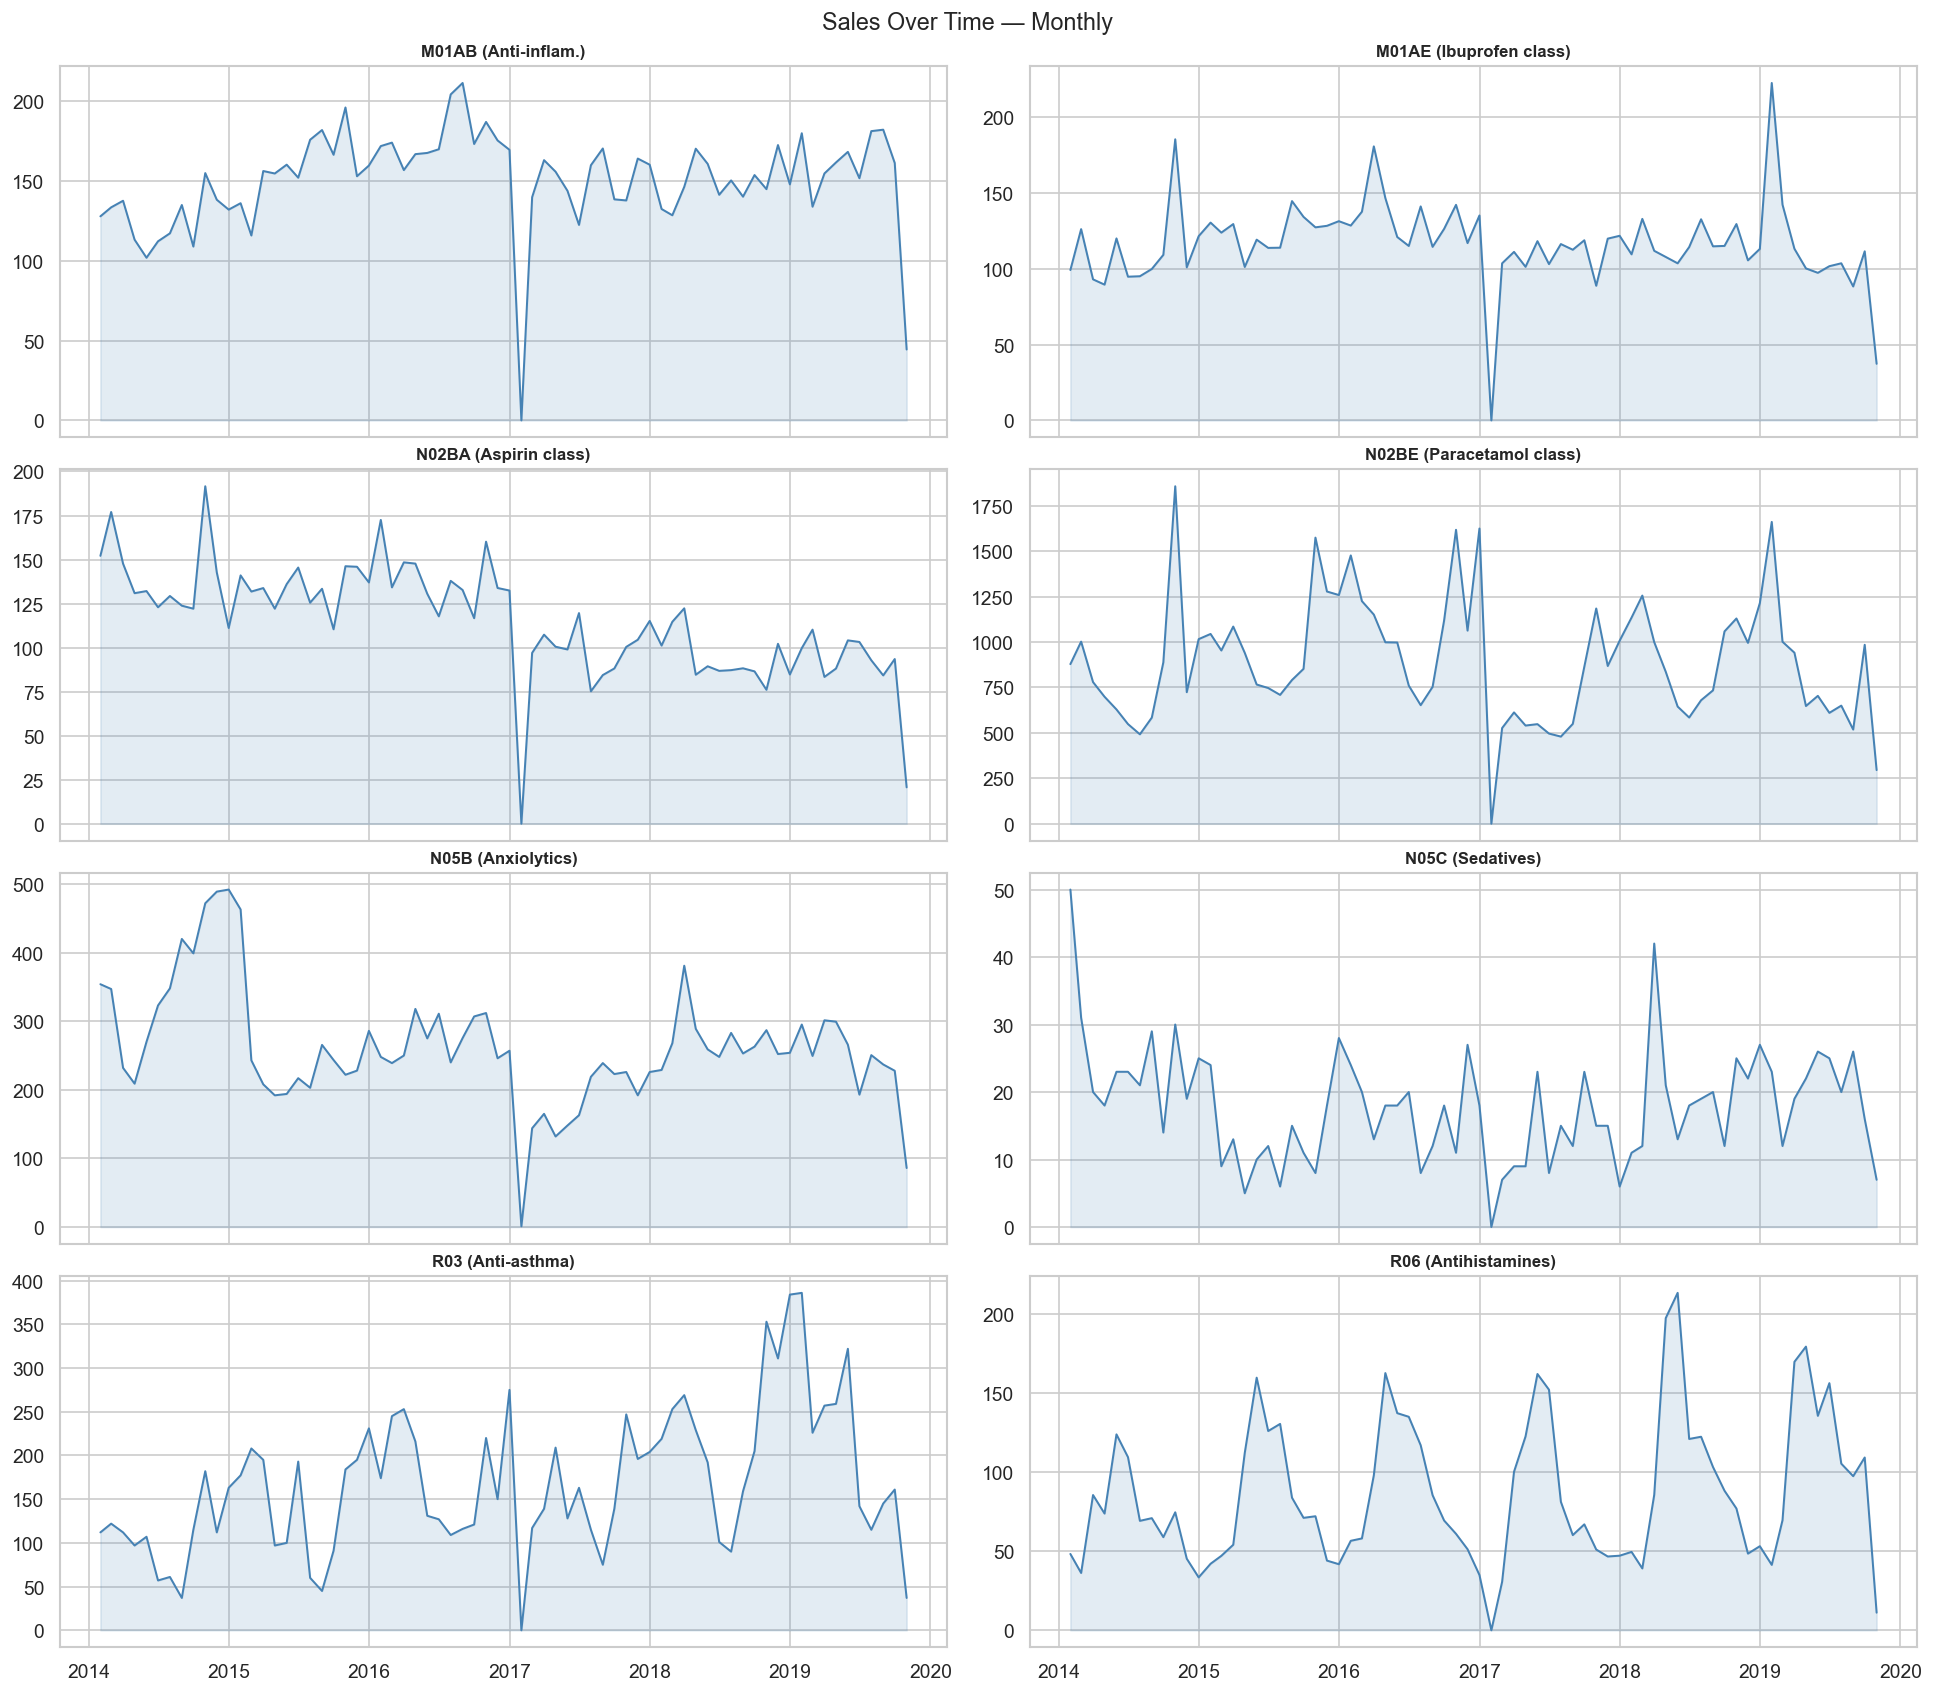

In [13]:
# Monthly time-series for all 8 drug categories
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True, constrained_layout=True)
fig.suptitle("Sales Over Time — Monthly", fontsize=14)

for ax, col in zip(axes.ravel(), DRUG_COLS):
    ax.plot(df_monthly["datum"], df_monthly[col], linewidth=1.2, color="steelblue")
    ax.fill_between(df_monthly["datum"], df_monthly[col], alpha=0.15, color="steelblue")
    ax.set_title(DRUG_LABELS[col], fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()

## 9. Top-Selling Medicines

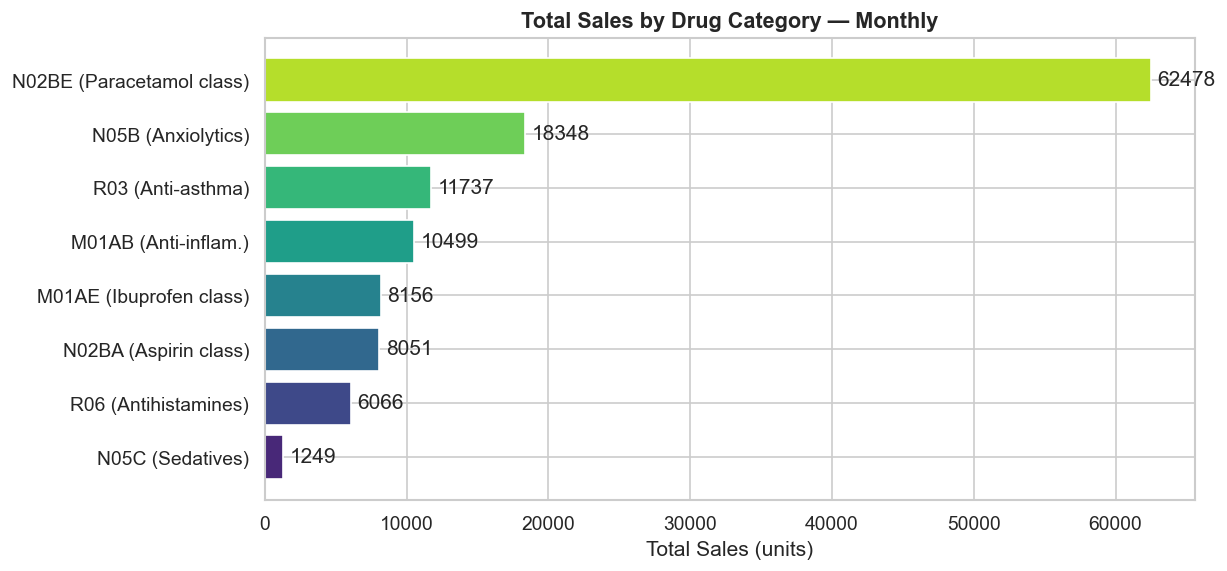


Top sellers:
  1. N02BE (Paracetamol class)      → 62,478
  2. N05B (Anxiolytics)             → 18,348
  3. R03 (Anti-asthma)              → 11,737
  4. M01AB (Anti-inflam.)           → 10,499
  5. M01AE (Ibuprofen class)        → 8,156
  6. N02BA (Aspirin class)          → 8,051
  7. R06 (Antihistamines)           → 6,066
  8. N05C (Sedatives)               → 1,249


In [14]:
# Total sales per drug category (entire period)
totals = df_monthly[DRUG_COLS].sum().sort_values(ascending=True)
labels = [DRUG_LABELS[c] for c in totals.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, totals.values, color=sns.color_palette("viridis", len(totals)))
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_title("Total Sales by Drug Category — Monthly", fontsize=13)
ax.set_xlabel("Total Sales (units)")
plt.show()

print("\nTop sellers:")
for i, (drug, val) in enumerate(totals[::-1].items(), 1):
    print(f"  {i}. {DRUG_LABELS[drug]:30s} → {val:,.0f}")

## 10. Seasonal Demand Trends

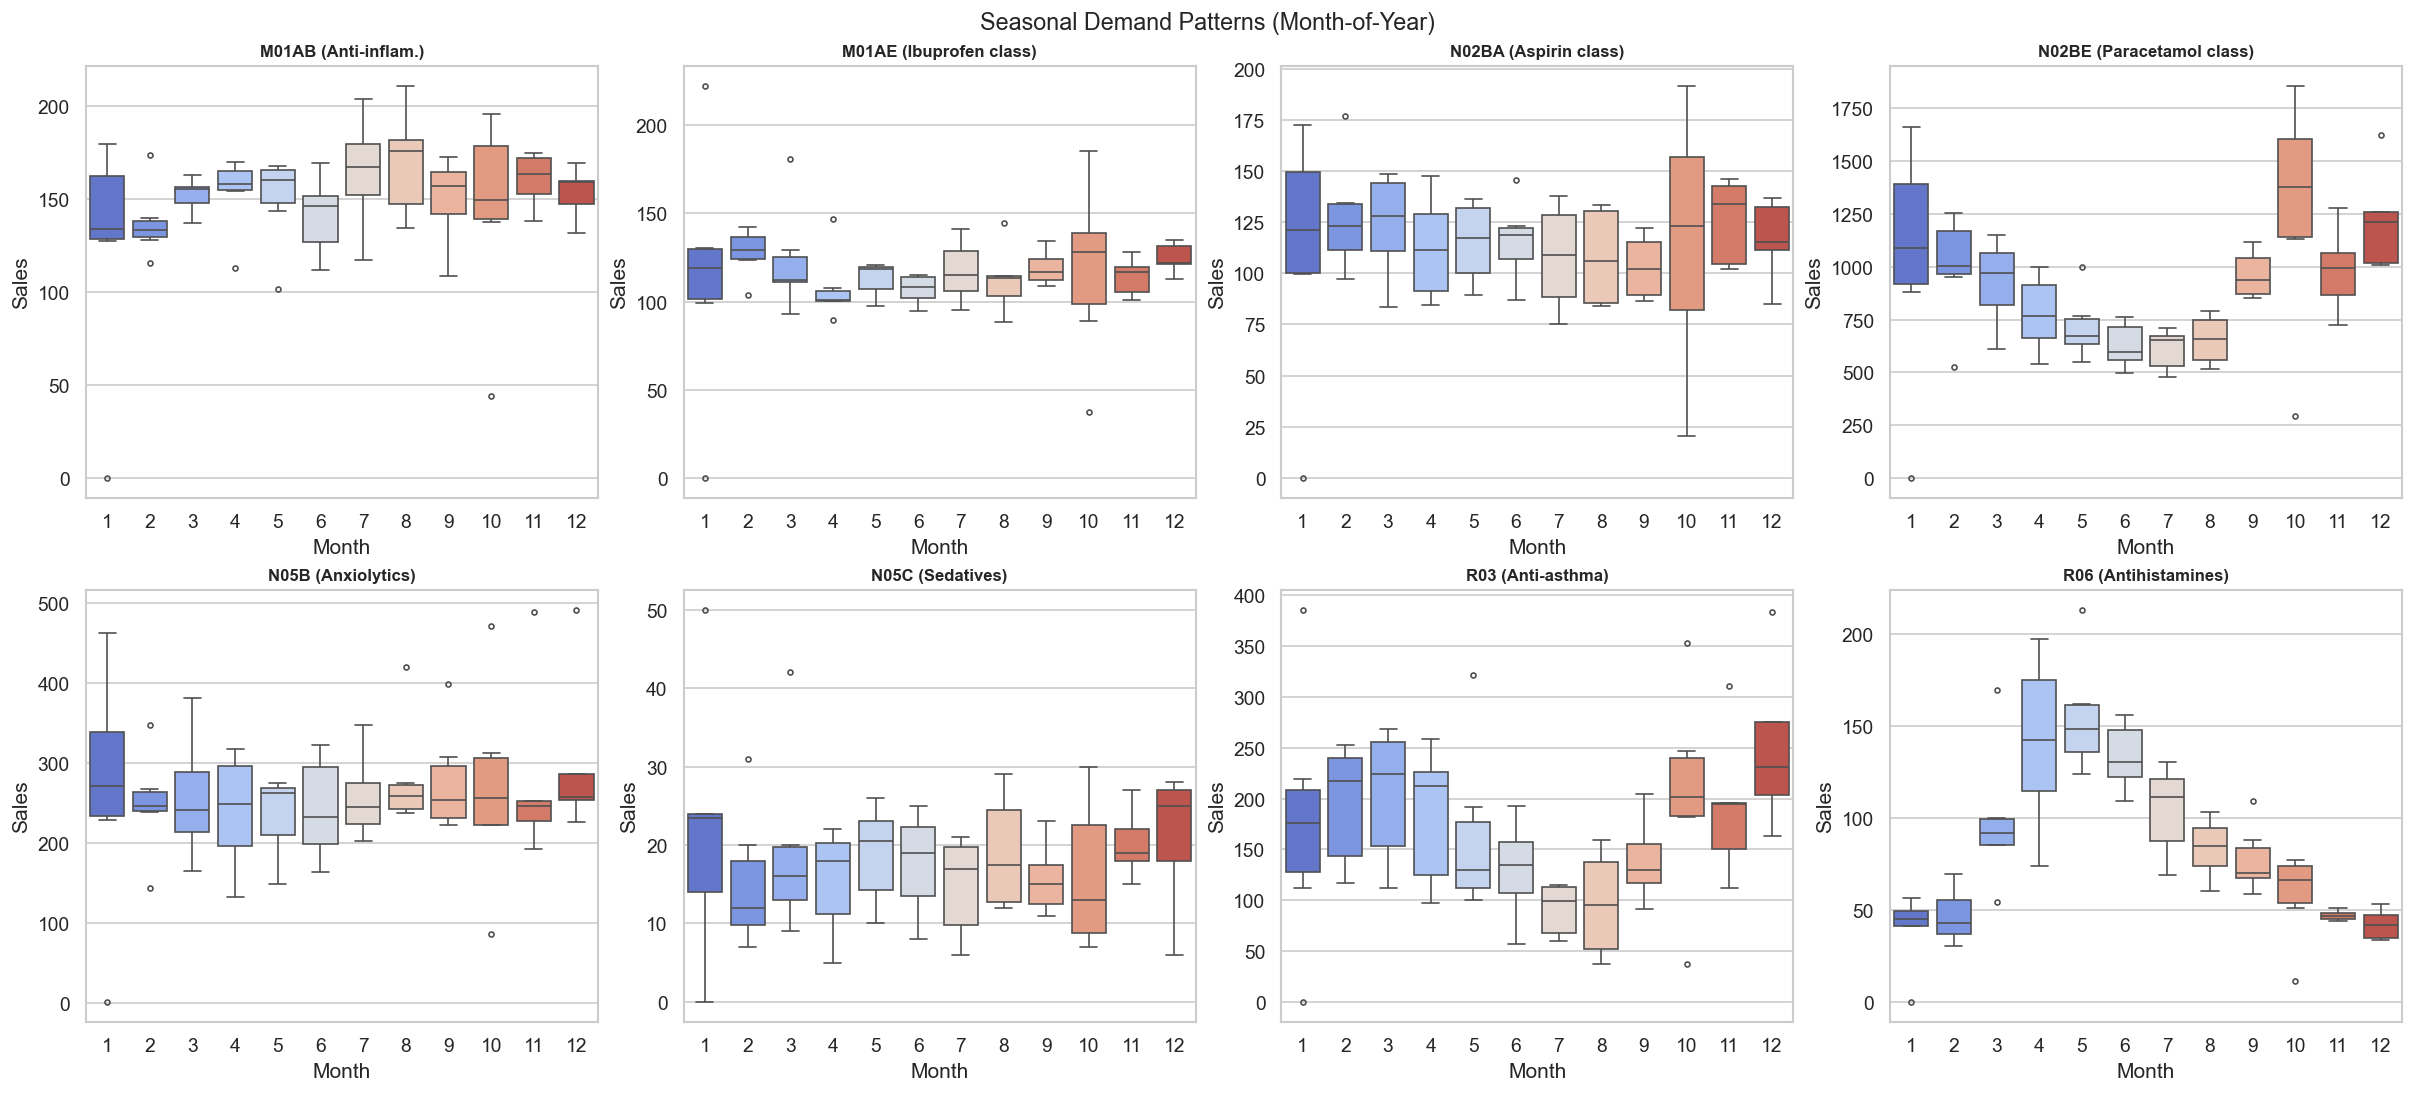

In [15]:
# Box plots: sales distribution by calendar month
df_m = df_monthly.copy()
df_m["month"] = df_m["datum"].dt.month

fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)
fig.suptitle("Seasonal Demand Patterns (Month-of-Year)", fontsize=14)

for ax, col in zip(axes.ravel(), DRUG_COLS):
    sns.boxplot(data=df_m, x="month", y=col, ax=ax, palette="coolwarm", fliersize=3)
    ax.set_title(DRUG_LABELS[col], fontsize=10)
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales")

plt.show()

## 11. Day-of-Week Patterns

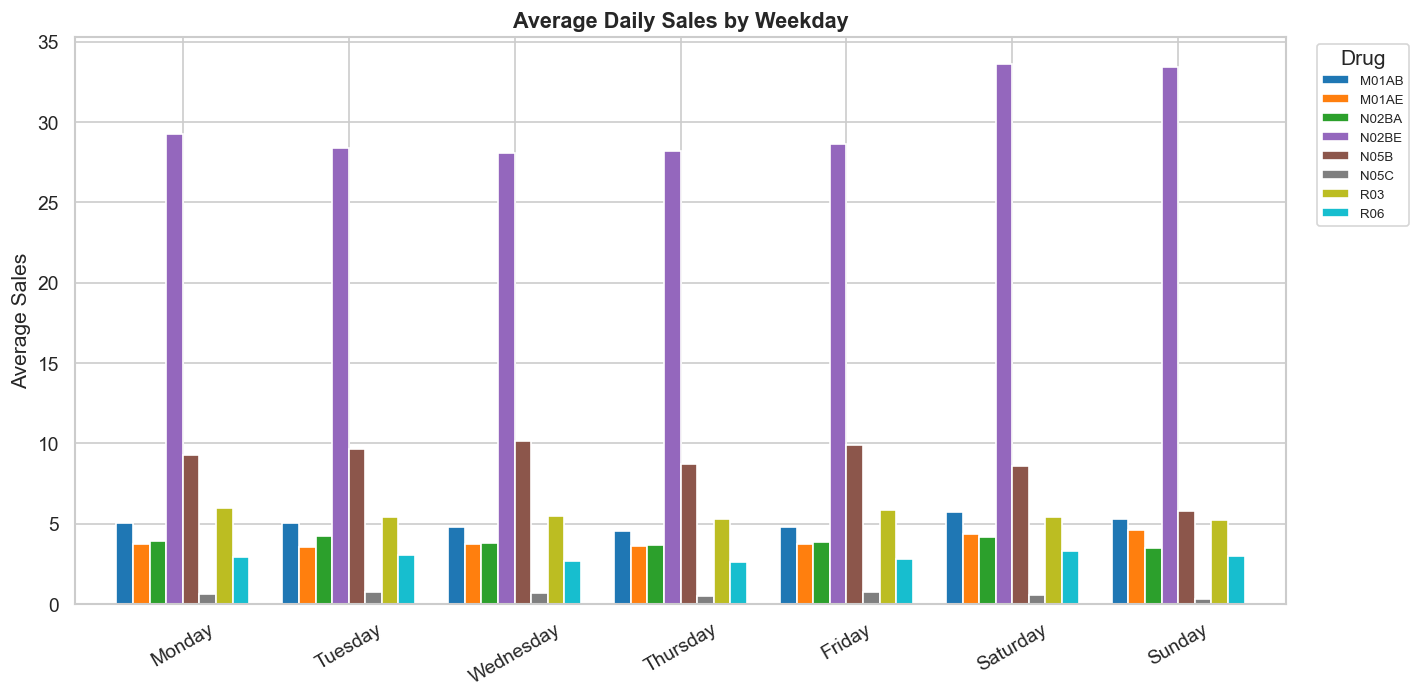

In [16]:
# Average daily sales by weekday
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_d = df_daily.copy()
df_d["Weekday Name"] = pd.Categorical(df_d["Weekday Name"], categories=day_order, ordered=True)
means = df_d.groupby("Weekday Name")[DRUG_COLS].mean()

fig, ax = plt.subplots(figsize=(12, 6))
means.plot(kind="bar", ax=ax, width=0.8, colormap="tab10")
ax.set_title("Average Daily Sales by Weekday", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Average Sales")
ax.legend(title="Drug", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 12. Hourly Demand Heatmap

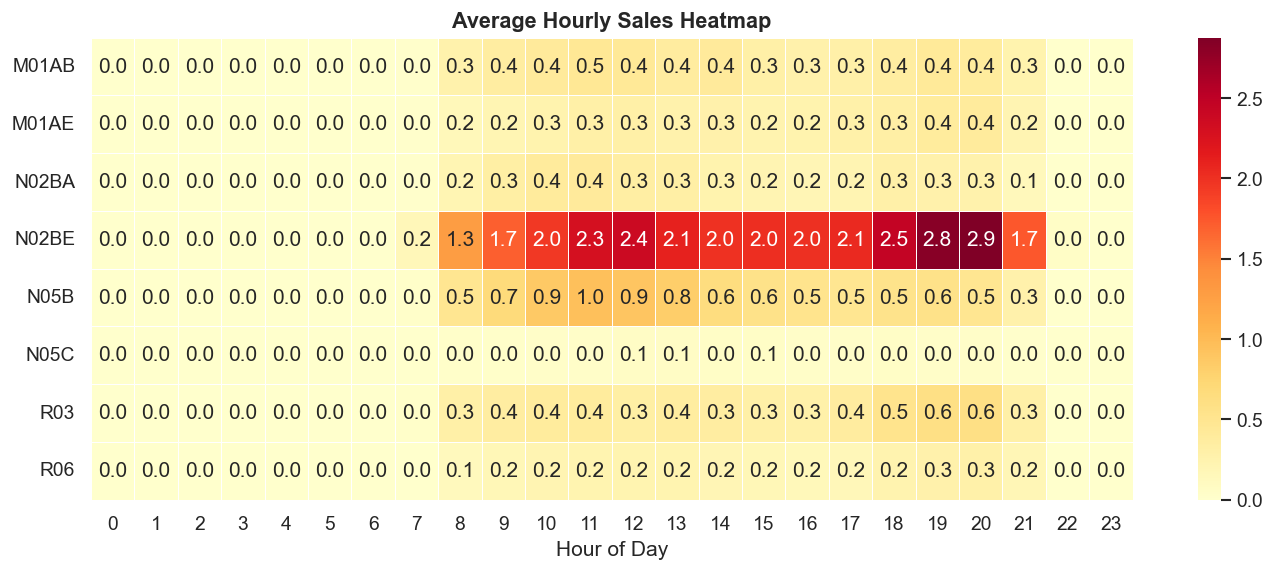

In [17]:
# Average sales per hour across drug categories
hourly_avg = df_hourly.groupby("Hour")[DRUG_COLS].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hourly_avg.T, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.3, ax=ax)
ax.set_title("Average Hourly Sales Heatmap", fontsize=13)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.show()

## 13. Year-over-Year Comparison

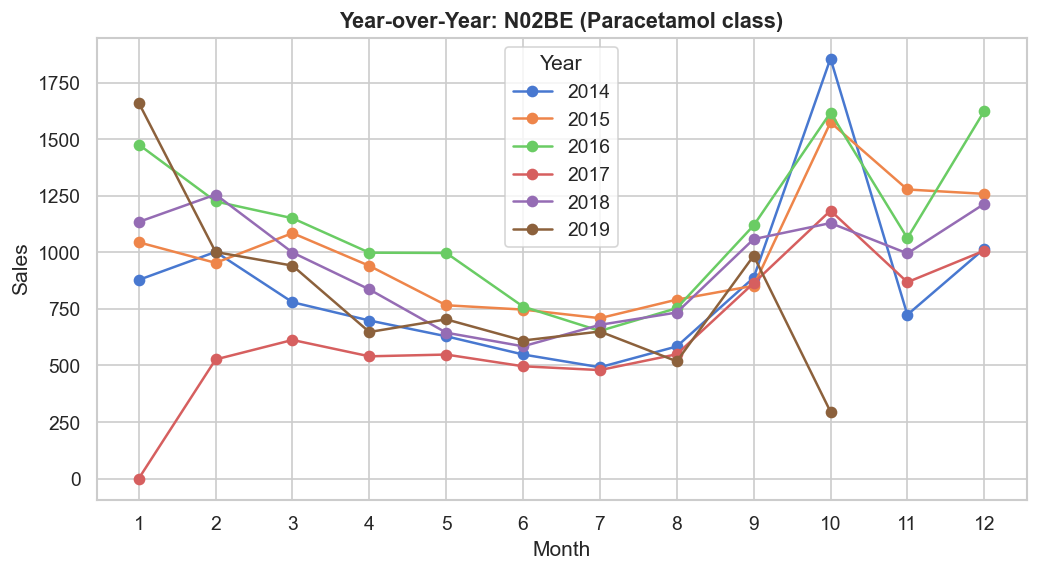

In [18]:
# Overlay annual curves for top-selling drug (N02BE — Paracetamol class)
df_yoy = df_monthly.copy()
df_yoy["year"] = df_yoy["datum"].dt.year
df_yoy["month"] = df_yoy["datum"].dt.month

fig, ax = plt.subplots(figsize=(10, 5))
for year, grp in df_yoy.groupby("year"):
    ax.plot(grp["month"], grp["N02BE"], marker="o", label=str(year), linewidth=1.5)

ax.set_title("Year-over-Year: N02BE (Paracetamol class)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")
plt.show()

## Key EDA Takeaways

1. **N02BE (Paracetamol)** dominates sales volume — roughly 5× the next category
2. **October** shows consistent demand spikes across analgesics (seasonal illness)
3. **January 2017** has anomalous all-zero data — likely a recording gap, not true zero sales
4. **Weekday patterns** show lower sales on Sundays across all categories
5. **Peak hours** are mid-morning to early afternoon (10:00–14:00)
6. **Low correlation** between most drug classes → each needs independent forecasting
7. **R03 (Anti-asthma)** and **R06 (Antihistamines)** show the highest variability (CV > 0.49)